# Inteligencia Artificial Avanzada
## Grupo C — Entrega N° 2

### Experimento 2 — CNN con GlobalAveragePooling2D

Este notebook corresponde al **Experimento 2** de la Entrega 2 y evalúa una simplificación de la arquitectura utilizada como línea base.

Se mantiene el mismo problema, dataset, clases y partición del Experimento 1, pero se reemplaza la capa `Flatten` por `GlobalAveragePooling2D`.

El objetivo del cambio es reducir significativamente la cantidad de parámetros entrenables y evaluar si una arquitectura más compacta mejora la capacidad de generalización del modelo.

### Configuración principal

- Dataset: 3.200 imágenes.
- Especies: 8 clases.
- División: 60% entrenamiento / 15% validación / 25% prueba.
- Resolución de entrada: 224 × 224 píxeles.
- Arquitectura:
  - Conv2D 32 + MaxPooling2D.
  - Conv2D 64 + MaxPooling2D.
  - Conv2D 128 + MaxPooling2D.
  - GlobalAveragePooling2D.
  - Dense de 128 neuronas.
  - Dropout 0,30.
  - Softmax de 8 clases.
- Optimizador: Adam.
- Learning rate: 0,001.

Esta configuración reduce los parámetros entrenables de aproximadamente 16,87 millones a 110.792 y es la arquitectura seleccionada como prototipo final de la Entrega 2 por presentar el mejor desempeño sobre el conjunto de prueba.

> **Nota de reproducibilidad:** los tres experimentos utilizan el mismo dataset balanceado, las mismas ocho clases, seed 42 y la misma partición train/validation/test. Las diferencias entre notebooks corresponden únicamente a las modificaciones indicadas para cada experimento.

In [ ]:
#@title 1. Configuración general

SEED = 42 #@param {type:"integer"}
MAX_IMAGES_PER_SPECIES = 400 #@param {type:"integer"}
MIN_IMAGES_RECOMMENDED = 100 #@param {type:"integer"}

IMG_SIZE = 224 #@param {type:"integer"}
BATCH_SIZE = 32 #@param {type:"integer"}
EPOCHS = 200 #@param {type:"integer"}
LEARNING_RATE = 0.001 #@param {type:"number"}

# La plantilla de la materia requiere al menos 25% de ejemplos para prueba.
TEST_FRACTION = 0.25
VAL_FRACTION_TOTAL = 0.15
TRAIN_FRACTION_TOTAL = 0.60

USE_GOOGLE_DRIVE = True #@param {type:"boolean"}
FORCE_REDOWNLOAD = False #@param {type:"boolean"}

# Recomendación para el prototipo:
# False = usar fotografías globales de la especie.
# Esto evita que el modelo aprenda "fondos de Buenos Aires" en vez de rasgos de la planta.
# La condición nativa/exótica se determina luego mediante el catálogo regional.
RESTRICT_OBSERVATIONS_TO_BA = False #@param {type:"boolean"}

print("Configuración cargada.")
print(f"Split objetivo: train={TRAIN_FRACTION_TOTAL:.0%}, val={VAL_FRACTION_TOTAL:.0%}, test={TEST_FRACTION:.0%}")

Configuración cargada.
Split objetivo: train=60%, val=15%, test=25%


In [ ]:
#@title 2. Librerías y reproducibilidad

import os
import re
import io
import json
import time
import shutil
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import requests

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
#@title 3. Acceder a Google Drive y preparar directorios

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/gdrive', force_remount=False)
    BASE_DIR = Path('/content/gdrive/MyDrive/2026_IAA_GrupoC')
else:
    BASE_DIR = Path('/content/2026_IAA_GrupoC')

RAW_DIR = BASE_DIR / 'dataset_raw'
SPLIT_DIR = BASE_DIR / 'dataset_split'
ARTIFACTS_DIR = BASE_DIR / 'artifacts_entrega2'

MANIFEST_PATH = BASE_DIR / 'manifest_inaturalist.csv'
BALANCED_MANIFEST_PATH = BASE_DIR / 'manifest_balanceado.csv'
SPLIT_MANIFEST_PATH = BASE_DIR / 'manifest_splits.csv'

for p in [BASE_DIR, RAW_DIR, ARTIFACTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("RAW_DIR:", RAW_DIR)
print("SPLIT_DIR:", SPLIT_DIR)
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
BASE_DIR: /content/gdrive/MyDrive/2026_IAA_GrupoC
RAW_DIR: /content/gdrive/MyDrive/2026_IAA_GrupoC/dataset_raw
SPLIT_DIR: /content/gdrive/MyDrive/2026_IAA_GrupoC/dataset_split
ARTIFACTS_DIR: /content/gdrive/MyDrive/2026_IAA_GrupoC/artifacts_entrega2


## 4. Catálogo inicial de especies

Para la prueba de concepto se trabaja con **8 clases visuales**. La lista está pensada para ser suficientemente acotada para la Entrega 2 y, al mismo tiempo, permitir evaluar un problema multiclase real.

> **Importante para el informe:** antes de cerrar la Entrega 2, conviene documentar para cada especie la referencia botánica concreta que respalda su condición regional. El código deja explícita la separación entre:
>
> **imagen → especie → condición regional**.

Si el grupo decide cambiar alguna especie, basta modificar la tabla de la siguiente celda y volver a descargar el dataset.

In [ ]:
import re
#@title 4.1 Catálogo de especies del prototipo

def slugify_species(name):
    """Convierte un nombre científico a un formato amigable para carpetas."""
    name = name.lower()
    name = re.sub(r'[^a-z0-9]+', '_', name) # Reemplaza no alfanuméricos con guiones bajos
    name = name.strip('_') # Elimina guiones bajos al inicio o final
    return name

SPECIES_CATALOG = pd.DataFrame([

    {
        "scientific_name": "Erythrina crista-galli",
        "common_name": "Ceibo",
        "condition_ba": "Nativa",
        "status_source": "Flora Argentina",

    },

    {
        "scientific_name": "Passiflora caerulea",
        "common_name": "Mburucuyá",
        "condition_ba": "Nativa",
        "status_source": "Flora Argentina",

    },

    {
        "scientific_name": "Cortaderia selloana",
        "common_name": "Cortadera",
        "condition_ba": "Nativa",
        "status_source": "Flora Argentina",

    },

    {
        "scientific_name": "Phytolacca dioica",
        "common_name": "Ombú",
        "condition_ba": "Nativa",
        "status_source": "Flora Argentina",

    },

    {
        "scientific_name": "Ligustrum lucidum",
        "common_name": "Ligustro",
        "condition_ba": "Exótica",
        "status_source": "Flora Argentina",

    },

    {
        "scientific_name": "Gleditsia triacanthos",
        "common_name": "Acacia negra",
        "condition_ba": "Exótica",
        "status_source": "Flora Argentina",

    },

    {
        "scientific_name": "Melia azedarach",
        "common_name": "Paraíso",
        "condition_ba": "Exótica",
        "status_source": "Flora Argentina",

    },

    {
        "scientific_name": "Iris pseudacorus",
        "common_name": "Lirio amarillo",
        "condition_ba": "Exótica",
        "status_source": "Flora Argentina",

    },

])

SPECIES_CATALOG["folder_name"] = (
    SPECIES_CATALOG["scientific_name"]
    .apply(slugify_species)
)

display(SPECIES_CATALOG)
print("\nCantidad de especies:", len(SPECIES_CATALOG))
print(SPECIES_CATALOG["condition_ba"].value_counts())

,scientific_name,common_name,condition_ba,status_source,status_url,folder_name
0,Erythrina crista-galli,Ceibo,Nativa,Flora Argentina,URL_ESPECIFICA_DEL_REGISTRO,erythrina_crista_galli
1,Passiflora caerulea,Mburucuyá,Nativa,Flora Argentina,URL_ESPECIFICA_DEL_REGISTRO,passiflora_caerulea
2,Cortaderia selloana,Cortadera,Nativa,Flora Argentina,URL_ESPECIFICA_DEL_REGISTRO,cortaderia_selloana
3,Phytolacca dioica,Ombú,Nativa,Flora Argentina,URL_ESPECIFICA_DEL_REGISTRO,phytolacca_dioica
4,Ligustrum lucidum,Ligustro,Exótica,Flora Argentina,URL_ESPECIFICA_DEL_REGISTRO,ligustrum_lucidum
5,Gleditsia triacanthos,Acacia negra,Exótica,Flora Argentina,URL_ESPECIFICA_DEL_REGISTRO,gleditsia_triacanthos
6,Melia azedarach,Paraíso,Exótica,Flora Argentina,URL_ESPECIFICA_DEL_REGISTRO,melia_azedarach
7,Iris pseudacorus,Lirio amarillo,Exótica,Flora Argentina,URL_ESPECIFICA_DEL_REGISTRO,iris_pseudacorus



Cantidad de especies: 8
condition_ba
Nativa     4
Exótica    4
Name: count, dtype: int64


In [ ]:
#@title 4.2 Validación del catálogo regional

required_fields = [
    "scientific_name",
    "condition_ba",
    "status_source",
    "status_url"
]

missing_catalog_data = (
    SPECIES_CATALOG[required_fields]
    .isna()
    .sum()
)

print("Campos faltantes:")
display(missing_catalog_data.to_frame("faltantes"))

print("\nCondiciones:")
display(
    SPECIES_CATALOG["condition_ba"]
    .value_counts()
    .rename("cantidad")
    .to_frame()
)

Campos faltantes:


,faltantes
scientific_name,0
condition_ba,0
status_source,0
status_url,0



Condiciones:


,cantidad
condition_ba,
Nativa,4
Exótica,4


## 5. Construcción del dataset desde iNaturalist

Se descargará **una sola fotografía por observación** para reducir el riesgo de tener tomas casi idénticas del mismo registro repartidas entre entrenamiento y prueba.

También se conservará un **manifest CSV** con:
- ID de observación;
- especie;
- condición regional;
- URL de la observación;
- URL de la foto;
- licencia;
- atribución;
- fecha y coordenadas cuando estén disponibles;
- ruta local.

Para el TP se filtran fotografías con licencias Creative Commons compatibles con uso académico y transformación de la imagen.

In [ ]:
#@title 5.1 Funciones para consultar iNaturalist y descargar imágenes

INAT_API = "https://api.inaturalist.org/v1"
SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "UTN-FRBA-IAA-TP-Plantas/1.0 (academic prototype)"
})

# Licencias de fotografía que admitimos en este prototipo.
ALLOWED_LICENSES = {
    "cc0",
    "cc-by",
    "cc-by-sa",
    "cc-by-nc",
    "cc-by-nc-sa",
}

# Bounding box aproximado de Provincia de Buenos Aires.
BA_BBOX = {
    "swlat": -41.2,
    "swlng": -63.6,
    "nelat": -33.2,
    "nelng": -56.4,
}

def resolve_taxon_id(scientific_name):
    """Busca el taxon_id de una especie en iNaturalist."""
    r = SESSION.get(
        f"{INAT_API}/taxa",
        params={"q": scientific_name, "rank": "species", "per_page": 10},
        timeout=30
    )
    r.raise_for_status()
    results = r.json().get("results", [])

    # Primero intenta coincidencia exacta.
    for taxon in results:
        if taxon.get("name", "").lower() == scientific_name.lower():
            return taxon["id"]

    # Si no existe coincidencia exacta, toma el primer resultado.
    if results:
        warnings.warn(
            f"No hubo coincidencia exacta para {scientific_name}. "
            f"Se utilizará: {results[0].get('name')}"
        )
        return results[0]["id"]

    raise ValueError(f"No se encontró taxón para: {scientific_name}")


def photo_medium_url(photo):
    """
    iNaturalist suele devolver una URL con tamaño 'square'.
    La reemplazamos por 'medium' para obtener una imagen útil sin bajar archivos enormes.
    """
    url = photo.get("url")
    if not url:
        return None
    return url.replace("/square.", "/medium.").replace("square.", "medium.")


def iter_observation_records(scientific_name, taxon_id, condition_ba, max_records):
    """Devuelve registros candidatos, uno por observación."""
    page = 1
    collected = 0
    seen_obs = set()

    while collected < max_records:
        params = {
            "taxon_id": taxon_id,
            "quality_grade": "research",
            "photos": "true",
            "per_page": 200,
            "page": page,
            "order_by": "created_at",
            "order": "desc",
        }

        if RESTRICT_OBSERVATIONS_TO_BA:
            params.update(BA_BBOX)

        r = SESSION.get(f"{INAT_API}/observations", params=params, timeout=45)
        r.raise_for_status()
        payload = r.json()
        results = payload.get("results", [])

        if not results:
            break

        for obs in results:
            obs_id = obs.get("id")
            if obs_id in seen_obs:
                continue
            seen_obs.add(obs_id)

            photos = obs.get("photos") or []
            if not photos:
                continue

            # Se toma una sola foto por observación.
            photo = photos[0]
            license_code = (photo.get("license_code") or "").lower()

            if license_code not in ALLOWED_LICENSES:
                continue

            url = photo_medium_url(photo)
            if not url:
                continue

            geojson = obs.get("geojson") or {}
            coords = geojson.get("coordinates") or [None, None]
            lng = coords[0] if len(coords) > 0 else None
            lat = coords[1] if len(coords) > 1 else None

            yield {
                "observation_id": obs_id,
                "scientific_name": scientific_name,
                "condition_ba": condition_ba,
                "observation_url": f"https://www.inaturalist.org/observations/{obs_id}",
                "photo_id": photo.get("id"),
                "photo_url": url,
                "license_code": license_code,
                "attribution": photo.get("attribution"),
                "observed_on": obs.get("observed_on"),
                "latitude": lat,
                "longitude": lng,
            }

            collected += 1
            if collected >= max_records:
                break

        page += 1
        if page > 20:
            break

        time.sleep(0.15)


def download_image(url, out_path):
    """Descarga, valida y normaliza una imagen a JPEG RGB."""
    r = SESSION.get(url, timeout=45)
    r.raise_for_status()

    img = Image.open(io.BytesIO(r.content)).convert("RGB")
    if min(img.size) < 80:
        raise ValueError(f"Imagen demasiado pequeña: {img.size}")

    out_path.parent.mkdir(parents=True, exist_ok=True)
    img.save(out_path, format="JPEG", quality=92)


def build_dataset_from_inaturalist():
    if FORCE_REDOWNLOAD and RAW_DIR.exists():
        print("FORCE_REDOWNLOAD=True -> borrando dataset_raw existente...")
        shutil.rmtree(RAW_DIR)
        RAW_DIR.mkdir(parents=True, exist_ok=True)

    if MANIFEST_PATH.exists() and not FORCE_REDOWNLOAD:
        print("Se encontró manifest existente. Se reutiliza:")
        print(MANIFEST_PATH)
        df = pd.read_csv(MANIFEST_PATH)
        return df

    records_downloaded = []

    for _, row in SPECIES_CATALOG.iterrows():
        species = row["scientific_name"]
        condition = row["condition_ba"]
        folder = RAW_DIR / row["folder_name"]

        print("\n" + "=" * 80)
        print("Especie:", species, "|", condition)

        taxon_id = resolve_taxon_id(species)
        print("taxon_id:", taxon_id)

        ok = 0
        errors = 0

        # Pedimos algo más que el objetivo porque algunas descargas pueden fallar.
        candidate_limit = int(MAX_IMAGES_PER_SPECIES * 1.5)

        for rec in iter_observation_records(
            scientific_name=species,
            taxon_id=taxon_id,
            condition_ba=condition,
            max_records=candidate_limit
        ):
            if ok >= MAX_IMAGES_PER_SPECIES:
                break

            out_path = folder / f"obs_{rec['observation_id']}_photo_{rec['photo_id']}.jpg"

            try:
                if not out_path.exists():
                    download_image(rec["photo_url"], out_path)

                rec["local_path"] = str(out_path)
                rec["folder_name"] = row["folder_name"]
                rec["common_name"] = row["common_name"]
                records_downloaded.append(rec)

                ok += 1

                if ok % 25 == 0:
                    print(f"  {ok}/{MAX_IMAGES_PER_SPECIES} imágenes válidas")

            except Exception as e:
                errors += 1
                if errors <= 3:
                    print("  Error descartado:", type(e).__name__, str(e)[:120])

        print(f"Final: {ok} imágenes válidas | {errors} errores de descarga/lectura")

    df = pd.DataFrame(records_downloaded)
    df.to_csv(MANIFEST_PATH, index=False)

    print("\nManifest guardado en:", MANIFEST_PATH)
    return df

In [ ]:
#@title 5.2 Descargar / reutilizar dataset

manifest = build_dataset_from_inaturalist()

print("\nTotal imágenes:", len(manifest))
display(
    manifest.groupby(["scientific_name", "condition_ba"])
            .size()
            .rename("cantidad")
            .reset_index()
)

Se encontró manifest existente. Se reutiliza:
/content/gdrive/MyDrive/2026_IAA_GrupoC/manifest_inaturalist.csv

Total imágenes: 3200


,scientific_name,condition_ba,cantidad
0,Cortaderia selloana,Nativa,400
1,Erythrina crista-galli,Nativa,400
2,Gleditsia triacanthos,Exótica,400
3,Iris pseudacorus,Exótica,400
4,Ligustrum lucidum,Exótica,400
5,Melia azedarach,Exótica,400
6,Passiflora caerulea,Nativa,400
7,Phytolacca dioica,Nativa,400


In [ ]:
#@title 6. Auditar dataset: archivos, cantidades y ejemplos

# Verifica que los archivos realmente existan.
manifest["file_exists"] = manifest["local_path"].apply(lambda p: Path(p).exists())
missing = (~manifest["file_exists"]).sum()
print("Archivos faltantes:", missing)

manifest = manifest[manifest["file_exists"]].copy()

counts = manifest["scientific_name"].value_counts().sort_index()
display(counts.rename("cantidad").to_frame())

plt.figure(figsize=(11, 4))
counts.plot(kind="bar")
plt.title("Cantidad de imágenes válidas por especie")
plt.ylabel("Imágenes")
plt.xlabel("Especie")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Muestra 2 ejemplos por especie.
n_per_class = 2
sample_df = (
    manifest.groupby("scientific_name", group_keys=False)
            .apply(lambda x: x.sample(min(n_per_class, len(x)), random_state=SEED))
            .reset_index(drop=True)
)

fig, axes = plt.subplots(len(SPECIES_CATALOG), n_per_class, figsize=(8, 3 * len(SPECIES_CATALOG)))
if len(SPECIES_CATALOG) == 1:
    axes = np.array([axes])

for ax in np.array(axes).reshape(-1):
    ax.axis("off")

for i, (_, row) in enumerate(sample_df.iterrows()):
    species_idx = list(SPECIES_CATALOG["scientific_name"]).index(row["scientific_name"])
    pos_in_species = sum(sample_df.iloc[:i]["scientific_name"] == row["scientific_name"])
    ax = axes[species_idx, pos_in_species]
    img = Image.open(row["local_path"])
    ax.imshow(img)
    ax.set_title(f"{row['scientific_name']}\n{row['condition_ba']}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

if counts.min() < MIN_IMAGES_RECOMMENDED:
    warnings.warn(
        f"La clase con menos imágenes tiene {counts.min()}. "
        "Conviene revisar la lista de especies o aumentar la descarga."
    )

## 7. Balanceo y partición

Para que la accuracy no quede dominada por las especies con más observaciones, el prototipo toma la **misma cantidad de imágenes por especie**, usando como límite la clase menos representada.

Luego se genera:

- **60% entrenamiento**
- **15% validación**
- **25% prueba**

La prueba permanece separada del entrenamiento y se usa únicamente para medir el desempeño final del prototipo.

In [ ]:
#@title 7.1 Balancear clases

counts = manifest.groupby("scientific_name").size()
n_balance = int(min(counts.min(), MAX_IMAGES_PER_SPECIES))

print("Cantidad balanceada por especie:", n_balance)

balanced = (
    manifest.groupby("scientific_name", group_keys=False)
            .apply(lambda x: x.sample(n=n_balance, random_state=SEED))
            .reset_index(drop=True)
)

balanced.to_csv(BALANCED_MANIFEST_PATH, index=False)

display(
    balanced.groupby(["scientific_name", "condition_ba"])
            .size()
            .rename("cantidad")
            .reset_index()
)

print("Total balanceado:", len(balanced))

Cantidad balanceada por especie: 400


/tmp/ipykernel_26820/3750194505.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=n_balance, random_state=SEED))


,scientific_name,condition_ba,cantidad
0,Cortaderia selloana,Nativa,400
1,Erythrina crista-galli,Nativa,400
2,Gleditsia triacanthos,Exótica,400
3,Iris pseudacorus,Exótica,400
4,Ligustrum lucidum,Exótica,400
5,Melia azedarach,Exótica,400
6,Passiflora caerulea,Nativa,400
7,Phytolacca dioica,Nativa,400


Total balanceado: 3200


In [ ]:
#@title 7.2 Separar 60% entrenamiento / 15% validación / 25% prueba

train_val_df, test_df = train_test_split(
    balanced,
    test_size=TEST_FRACTION,
    random_state=SEED,
    stratify=balanced["scientific_name"]
)

# El 15% del total equivale al 20% del bloque restante (75%).
val_fraction_of_remaining = VAL_FRACTION_TOTAL / (1.0 - TEST_FRACTION)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_fraction_of_remaining,
    random_state=SEED,
    stratify=train_val_df["scientific_name"]
)

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

split_manifest = pd.concat([train_df, val_df, test_df], ignore_index=True)
split_manifest.to_csv(SPLIT_MANIFEST_PATH, index=False)

print("Cantidades:")
print(split_manifest["split"].value_counts())
print("\nPorcentajes reales:")
print(split_manifest["split"].value_counts(normalize=True).sort_index())

print("\nDistribución por especie y split:")
display(pd.crosstab(split_manifest["scientific_name"], split_manifest["split"]))

Cantidades:
split
train    1920
test      800
val       480
Name: count, dtype: int64

Porcentajes reales:
split
test     0.25
train    0.60
val      0.15
Name: proportion, dtype: float64

Distribución por especie y split:


split,test,train,val
scientific_name,,,
Cortaderia selloana,100,240,60
Erythrina crista-galli,100,240,60
Gleditsia triacanthos,100,240,60
Iris pseudacorus,100,240,60
Ligustrum lucidum,100,240,60
Melia azedarach,100,240,60
Passiflora caerulea,100,240,60
Phytolacca dioica,100,240,60


In [ ]:
#@title 7.3 Auditoría cuantitativa del dataset

# ============================================================
# Distribución por especie y split
# ============================================================

audit_species = pd.crosstab(
    split_manifest["scientific_name"],
    split_manifest["split"]
)

# Orden deseado
for col in ["train", "val", "test"]:
    if col not in audit_species.columns:
        audit_species[col] = 0

audit_species = audit_species[
    ["train", "val", "test"]
]

audit_species["total"] = audit_species.sum(axis=1)

print("Distribución por especie:")
display(audit_species)


# ============================================================
# Distribución por condición regional
# ============================================================

audit_condition = pd.crosstab(
    split_manifest["condition_ba"],
    split_manifest["split"]
)

for col in ["train", "val", "test"]:
    if col not in audit_condition.columns:
        audit_condition[col] = 0

audit_condition = audit_condition[
    ["train", "val", "test"]
]

audit_condition["total"] = audit_condition.sum(axis=1)

print("\nDistribución por condición:")
display(audit_condition)


# ============================================================
# Resumen general
# ============================================================

dataset_summary = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Validación", "Prueba", "Total"],
    "Cantidad": [
        len(train_df),
        len(val_df),
        len(test_df),
        len(split_manifest)
    ]
})

dataset_summary["Porcentaje"] = (
    dataset_summary["Cantidad"] /
    len(split_manifest) * 100
)

# El total debe mostrarse como 100%
dataset_summary.loc[
    dataset_summary["Conjunto"] == "Total",
    "Porcentaje"
] = 100

print("\nResumen del dataset:")
display(dataset_summary)


# ============================================================
# Validaciones automáticas
# ============================================================

print("\nControles:")

print(
    "Cantidad de especies:",
    split_manifest["scientific_name"].nunique()
)

print(
    "Cantidad de condiciones:",
    split_manifest["condition_ba"].nunique()
)

print(
    "Duplicados observation_id:",
    split_manifest["observation_id"].duplicated().sum()
)

print(
    "Duplicados local_path:",
    split_manifest["local_path"].duplicated().sum()
)


# Verifica que una observación no haya quedado en más de un split
obs_split_count = (
    split_manifest
    .groupby("observation_id")["split"]
    .nunique()
)

leakage_count = (obs_split_count > 1).sum()

print(
    "Observaciones presentes en más de un split:",
    leakage_count
)


if leakage_count == 0:
    print("✅ No se detectó leakage por observation_id.")
else:
    print("⚠️ Revisar separación del dataset.")


# ============================================================
# Guardar tablas
# ============================================================

audit_species.to_csv(
    ARTIFACTS_DIR / "auditoria_especies_split.csv"
)

audit_condition.to_csv(
    ARTIFACTS_DIR / "auditoria_condicion_split.csv"
)

dataset_summary.to_csv(
    ARTIFACTS_DIR / "auditoria_resumen_dataset.csv",
    index=False
)

Distribución por especie:


split,train,val,test,total
scientific_name,,,,
Cortaderia selloana,240,60,100,400
Erythrina crista-galli,240,60,100,400
Gleditsia triacanthos,240,60,100,400
Iris pseudacorus,240,60,100,400
Ligustrum lucidum,240,60,100,400
Melia azedarach,240,60,100,400
Passiflora caerulea,240,60,100,400
Phytolacca dioica,240,60,100,400



Distribución por condición:


split,train,val,test,total
condition_ba,,,,
Exótica,960,240,400,1600
Nativa,960,240,400,1600



Resumen del dataset:


,Conjunto,Cantidad,Porcentaje
0,Entrenamiento,1920,60.0
1,Validación,480,15.0
2,Prueba,800,25.0
3,Total,3200,100.0



Controles:
Cantidad de especies: 8
Cantidad de condiciones: 2
Duplicados observation_id: 0
Duplicados local_path: 0
Observaciones presentes en más de un split: 0
✅ No se detectó leakage por observation_id.


In [ ]:
#@title 7.3 Crear estructura de carpetas train / val / test (Optimizado)

from concurrent.futures import ThreadPoolExecutor
import shutil

def copy_task(args):
    src, dst_dir = args
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst = dst_dir / src.name
    if not dst.exists():
        shutil.copy2(src, dst)

if SPLIT_DIR.exists():
    print(f"Limpiando directorio existente: {SPLIT_DIR}...")
    shutil.rmtree(SPLIT_DIR)

tasks = []
for split_name, df_split in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df),
]:
    for _, row in df_split.iterrows():
        src = Path(row["local_path"])
        dst_dir = SPLIT_DIR / split_name / row["folder_name"]
        tasks.append((src, dst_dir))

print(f"Iniciando copiado paralelo de {len(tasks)} archivos...")
# Usamos hilos para mitigar la latencia de E/S en Drive
with ThreadPoolExecutor(max_workers=8) as executor:
    list(executor.map(copy_task, tasks))

print("Estructura generada en:", SPLIT_DIR)

for split_name in ["train", "val", "test"]:
    # Conteo rápido usando rglob y len
    total = len(list((SPLIT_DIR / split_name).rglob("*.jpg")))
    print(f"{split_name}: {total} imágenes")

Limpiando directorio existente: /content/gdrive/MyDrive/2026_IAA_GrupoC/dataset_split...
Iniciando copiado paralelo de 3200 archivos...
Estructura generada en: /content/gdrive/MyDrive/2026_IAA_GrupoC/dataset_split
train: 1920 imágenes
val: 480 imágenes
test: 800 imágenes


## 8. Carga de imágenes

La cátedra trabaja sus demos con imágenes organizadas en directorios por clase. Se conserva esa lógica, pero se utiliza `image_dataset_from_directory` para leerlas por lotes y evitar cargar todo el dataset simultáneamente en memoria.

En este experimento no se aplica **Data Augmentation**, con el objetivo de mantener una línea base clara. Esta técnica se evalúa posteriormente en el Experimento 3 de la misma Entrega 2.

In [ ]:
#@title 8.1 Crear datasets TensorFlow (Optimizado)

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "train",
    labels="inferred",
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "val",
    labels="inferred",
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "test",
    labels="inferred",
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

CLASS_NAMES = train_ds_raw.class_names
NUM_CLASSES = len(CLASS_NAMES)

print("\nClases detectadas:")
for i, c in enumerate(CLASS_NAMES):
    print(i, "->", c)

# Optimización del Pipeline de Datos
AUTOTUNE = tf.data.AUTOTUNE

# .cache() mantiene las imágenes en memoria tras la primera lectura
# .prefetch() permite que el CPU prepare el siguiente batch mientras la GPU entrena el actual
train_ds = train_ds_raw.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds_raw.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds_raw.cache().prefetch(buffer_size=AUTOTUNE)

TEST_FILE_PATHS = list(test_ds_raw.file_paths)

Found 1920 files belonging to 8 classes.
Found 480 files belonging to 8 classes.
Found 800 files belonging to 8 classes.

Clases detectadas:
0 -> Cortaderia_selloana
1 -> Erythrina_crista-galli
2 -> Gleditsia_triacanthos
3 -> Iris_pseudacorus
4 -> Ligustrum_lucidum
5 -> Melia_azedarach
6 -> Passiflora_caerulea
7 -> Phytolacca_dioica


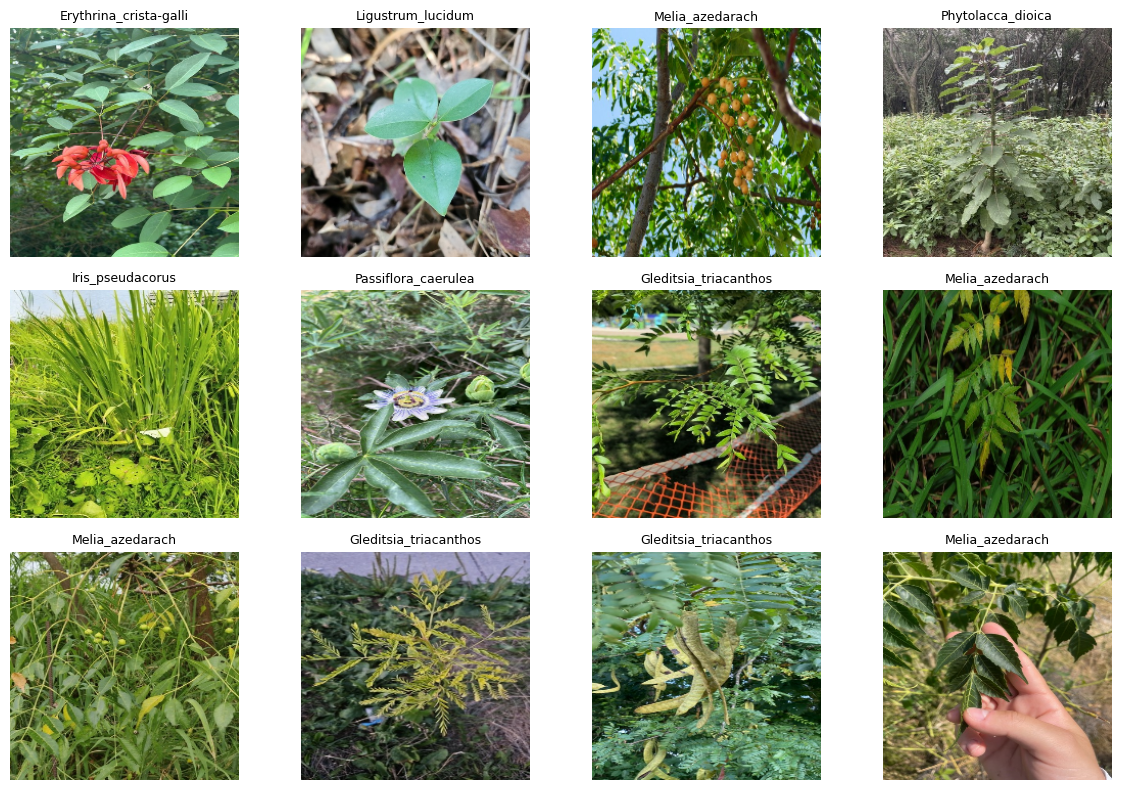

In [ ]:
#@title 8.2 Visualizar un batch de entrenamiento

images_batch, labels_batch = next(iter(train_ds))

plt.figure(figsize=(12, 8))
for i in range(min(12, len(images_batch))):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(images_batch[i].numpy().astype("uint8"))
    class_idx = int(np.argmax(labels_batch[i].numpy()))
    plt.title(CLASS_NAMES[class_idx], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

# 9. Prototipo CNN

La arquitectura mantiene los tres bloques convolucionales utilizados en el Experimento 1, pero reemplaza `Flatten` por `GlobalAveragePooling2D`:

**Entrada → Rescaling → Conv2D + Pooling → Conv2D + Pooling → Conv2D + Pooling → GlobalAveragePooling2D → Dense → Dropout → Softmax**

Esta modificación reduce significativamente la cantidad de parámetros entrenables y permite evaluar una arquitectura más compacta y con menor capacidad de memorización.

In [ ]:
#@title 9.1 Definir y compilar ConvNet

model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_img"),
    layers.Rescaling(1./255, name="rescaling"),

    layers.Conv2D(32, 3, padding="same", activation="relu", name="conv_1"),
    layers.MaxPooling2D(name="pool_1"),

    layers.Conv2D(64, 3, padding="same", activation="relu", name="conv_2"),
    layers.MaxPooling2D(name="pool_2"),

    layers.Conv2D(128, 3, padding="same", activation="relu", name="conv_3"),
    layers.MaxPooling2D(name="pool_3"),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),


    layers.Dropout(0.30, name="dropout"),
    layers.Dense(NUM_CLASSES, activation="softmax", name="output")
], name="ConvNet_Plantas_Entrega2")

optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "ConvNet_Plantas_Entrega2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,792 (432.78 KB)

 Trainable params: 110,792 (432.78 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - accuracy: 0.1490 - loss: 2.0661 - val_accuracy: 0.2542 - val_loss: 2.0146
Epoch 2/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - accuracy: 0.2391 - loss: 1.9591 - val_accuracy: 0.2792 - val_loss: 1.8813
Epoch 3/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.2828 - loss: 1.8720 - val_accuracy: 0.2979 - val_loss: 1.8309
Epoch 4/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.2917 - loss: 1.8350 - val_accuracy: 0.3292 - val_loss: 1.8345
Epoch 5/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.3094 - loss: 1.8071 - val_accuracy: 0.3333 - val_loss: 1.7552
Epoch 6/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.3161 - loss: 1.7879 - val_accuracy: 0.3250 - val_loss: 1.7720
Epoch 7/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.3240 - loss: 1.7720 - val_accuracy: 0.2979 - val_loss: 1.7905
Epoch 8/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.3245 - loss: 1.7687 - val_accuracy: 

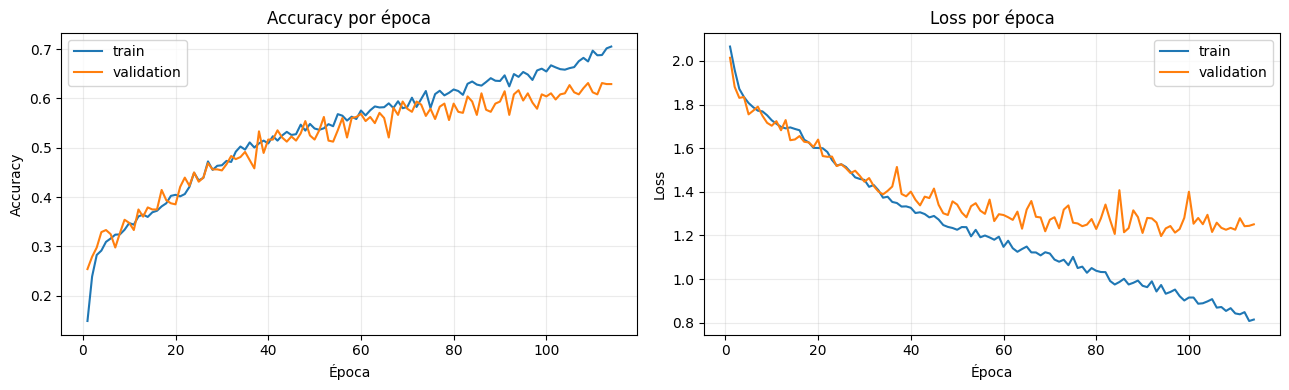

In [ ]:
#@title 9.3 Curvas de entrenamiento y validación

hist = pd.DataFrame(history.history)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(hist.index + 1, hist["accuracy"], label="train")
ax[0].plot(hist.index + 1, hist["val_accuracy"], label="validation")
ax[0].set_title("Accuracy por época")
ax[0].set_xlabel("Época")
ax[0].set_ylabel("Accuracy")
ax[0].legend()
ax[0].grid(alpha=0.25)

ax[1].plot(hist.index + 1, hist["loss"], label="train")
ax[1].plot(hist.index + 1, hist["val_loss"], label="validation")
ax[1].set_title("Loss por época")
ax[1].set_xlabel("Época")
ax[1].set_ylabel("Loss")
ax[1].legend()
ax[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

fig.savefig(ARTIFACTS_DIR / "curvas_entrenamiento.png", dpi=160, bbox_inches="tight")

# 10. Evaluación del prototipo

Se evalúan **dos niveles**:

### A. Identificación de especie
Problema multiclase de 8 clases.

### B. Condición nativa/exótica
Se deriva a partir de la especie predicha.  
Esto permite separar correctamente el problema visual del conocimiento botánico regional.

In [ ]:
#@title 10.1 Evaluación global en prueba

test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.6112 - loss: 1.1596

Test loss: 1.1596
Test accuracy: 0.6112


In [ ]:
#@title 10.2 Predicciones y métricas por especie

y_true_onehot = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_true = np.argmax(y_true_onehot, axis=1)

y_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_conf = np.max(y_prob, axis=1)

species_report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

species_report_df = pd.DataFrame(species_report).T
display(species_report_df)

species_macro_f1 = f1_score(y_true, y_pred, average="macro")
species_accuracy = accuracy_score(y_true, y_pred)

print(f"Accuracy especie: {species_accuracy:.4f}")
print(f"Macro-F1 especie: {species_macro_f1:.4f}")

species_report_df.to_csv(ARTIFACTS_DIR / "classification_report_especies.csv")

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


,precision,recall,f1-score,support
Cortaderia_selloana,0.771186,0.91000,0.834862,100.00000
Erythrina_crista-galli,0.737374,0.73000,0.733668,100.00000
Gleditsia_triacanthos,0.438356,0.64000,0.520325,100.00000
Iris_pseudacorus,0.894118,0.76000,0.821622,100.00000
Ligustrum_lucidum,0.526882,0.49000,0.507772,100.00000
Melia_azedarach,0.419355,0.13000,0.198473,100.00000
Passiflora_caerulea,0.714286,0.55000,0.621469,100.00000
Phytolacca_dioica,0.450331,0.68000,0.541833,100.00000
accuracy,0.611250,0.61125,0.611250,0.61125
macro avg,0.618986,0.61125,0.597503,800.00000


Accuracy especie: 0.6112
Macro-F1 especie: 0.5975


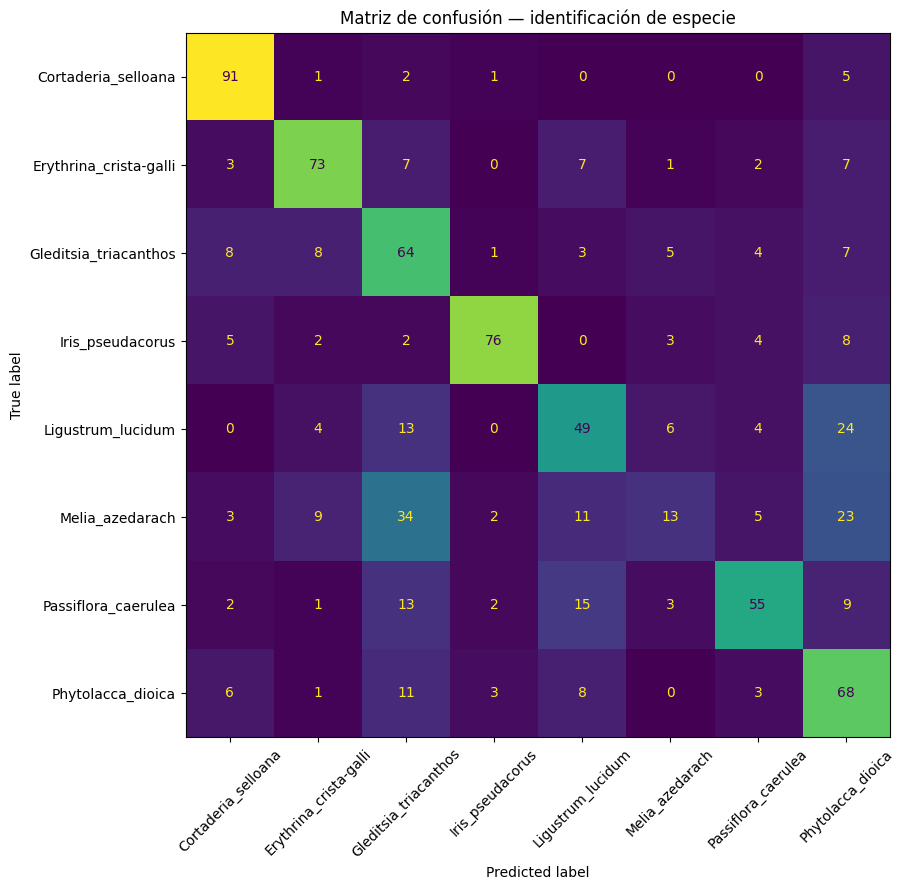

In [ ]:
#@title 10.3 Matriz de confusión por especie

cm_species = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 9))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_species,
    display_labels=CLASS_NAMES
)
disp.plot(ax=ax, xticks_rotation=45, values_format="d", colorbar=False)
plt.title("Matriz de confusión — identificación de especie")
plt.tight_layout()
plt.show()

fig.savefig(ARTIFACTS_DIR / "matriz_confusion_especies.png", dpi=170, bbox_inches="tight")

In [ ]:
#@title 10.4 Evaluar clasificación derivada Nativa / Exótica

# Aseguramos que el índice del catálogo sea consistente (slugify)
catalog_by_folder = SPECIES_CATALOG.set_index("folder_name")

# Mapeo de clase -> condición, normalizando el nombre de la clase al formato del catálogo
class_to_condition = {}
for class_name in CLASS_NAMES:
    # Aplicamos la misma función de slugify para garantizar coincidencia de llaves
    slug_name = slugify_species(class_name)
    if slug_name in catalog_by_folder.index:
        class_to_condition[class_name] = catalog_by_folder.loc[slug_name, "condition_ba"]
    else:
        # Fallback por si hay diferencias de guiones/puntos
        class_to_condition[class_name] = "Desconocido"

true_species_names = [CLASS_NAMES[i] for i in y_true]
pred_species_names = [CLASS_NAMES[i] for i in y_pred]

y_true_condition = np.array([class_to_condition[s] for s in true_species_names])
y_pred_condition = np.array([class_to_condition[s] for s in pred_species_names])

condition_labels = ["Nativa", "Exótica"]

condition_report = classification_report(
    y_true_condition,
    y_pred_condition,
    labels=condition_labels,
    output_dict=True,
    zero_division=0
)

condition_report_df = pd.DataFrame(condition_report).T
display(condition_report_df)

condition_accuracy = accuracy_score(y_true_condition, y_pred_condition)
condition_macro_f1 = f1_score(
    y_true_condition,
    y_pred_condition,
    labels=condition_labels,
    average="macro"
)

print(f"Accuracy condición: {condition_accuracy:.4f}")
print(f"Macro-F1 condición: {condition_macro_f1:.4f}")

condition_report_df.to_csv(ARTIFACTS_DIR / "classification_report_condicion.csv")

,precision,recall,f1-score,support
Nativa,0.734831,0.81750,0.773964,400.00000
Exótica,0.794366,0.70500,0.747020,400.00000
accuracy,0.761250,0.76125,0.761250,0.76125
macro avg,0.764599,0.76125,0.760492,800.00000
weighted avg,0.764599,0.76125,0.760492,800.00000


Accuracy condición: 0.7612
Macro-F1 condición: 0.7605


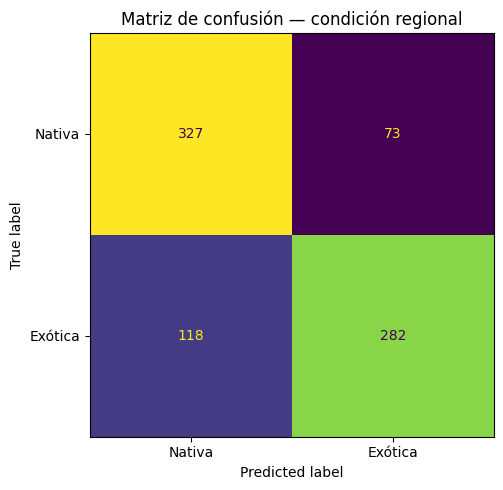

In [ ]:
#@title 10.5 Matriz de confusión Nativa / Exótica

cm_condition = confusion_matrix(
    y_true_condition,
    y_pred_condition,
    labels=condition_labels
)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_condition,
    display_labels=condition_labels
)
disp.plot(ax=ax, values_format="d", colorbar=False)
plt.title("Matriz de confusión — condición regional")
plt.tight_layout()
plt.show()

fig.savefig(ARTIFACTS_DIR / "matriz_confusion_condicion.png", dpi=170, bbox_inches="tight")

In [ ]:
#@title 10.6 Tabla de resultados de prueba

# image_dataset_from_directory con shuffle=False conserva el orden de file_paths.
results_test = pd.DataFrame({
    "file_path": TEST_FILE_PATHS,
    "real_species": true_species_names,
    "pred_species": pred_species_names,
    "confidence": y_conf,
    "real_condition": y_true_condition,
    "pred_condition": y_pred_condition,
})

results_test["species_correct"] = results_test["real_species"] == results_test["pred_species"]
results_test["condition_correct"] = results_test["real_condition"] == results_test["pred_condition"]

display(results_test.head(20))

results_test.to_csv(ARTIFACTS_DIR / "resultados_test.csv", index=False)

print("\nErrores de especie:", (~results_test["species_correct"]).sum())
print("Errores de condición:", (~results_test["condition_correct"]).sum())

,file_path,real_species,pred_species,confidence,real_condition,pred_condition,species_correct,condition_correct
0,/content/gdrive/MyDrive/2026_IAA_GrupoC/datase...,Cortaderia_selloana,Cortaderia_selloana,0.982496,Nativa,Nativa,True,True
1,/content/gdrive/MyDrive/2026_IAA_GrupoC/datase...,Cortaderia_selloana,Cortaderia_selloana,0.329031,Nativa,Nativa,True,True
2,/content/gdrive/MyDrive/2026_IAA_GrupoC/datase...,Cortaderia_selloana,Cortaderia_selloana,0.995970,Nativa,Nativa,True,True
3,/content/gdrive/MyDrive/2026_IAA_GrupoC/datase...,Cortaderia_selloana,Cortaderia_selloana,0.981590,Nativa,Nativa,True,True
4,/content/gdrive/MyDrive/2026_IAA_GrupoC/datase...,Cortaderia_selloana,Cortaderia_selloana,0.957266,Nativa,Nativa,True,True
5,/content/gdrive/MyDrive/2026_IAA_GrupoC/datase...,Cortaderia_selloana,Cortaderia_selloana,0.996978,Nativa,Nativa,True,True
6,/content/gdrive/MyDrive/2026_IAA_GrupoC/datase...,Cortaderia_selloana,Cortaderia_selloana,0.984180,Nativa,Nativa,True,True
7,/content/gdrive/MyDrive/2026_IAA_GrupoC/datase...,Cortaderia_selloana,Cortaderia_selloana,0.992478,Nativa,Nativa,True,True
8,/content/gdrive/MyDrive/2026_IAA_GrupoC/datase...,Cortaderia_selloana,Cortaderia_selloana,0.959278,Nativa,Nativa,True,True
9,/content/gdrive/MyDrive/2026_IAA_GrupoC/datase...,Cortaderia_selloana,Cortaderia_selloana,0.690417,Nativa,Nativa,True,True



Errores de especie: 311
Errores de condición: 191


# 11. Análisis de errores

Esta sección es particularmente útil para el informe


In [ ]:
#@title 11.1 Mostrar errores de clasificación más confiados

errors_df = results_test[~results_test["species_correct"]].copy()
errors_df = errors_df.sort_values("confidence", ascending=False)

N_ERRORS_TO_SHOW = min(16, len(errors_df))

if N_ERRORS_TO_SHOW == 0:
    print("No hubo errores de especie en el conjunto de prueba.")
else:
    cols = 4
    rows = int(np.ceil(N_ERRORS_TO_SHOW / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, (_, row) in zip(axes, errors_df.head(N_ERRORS_TO_SHOW).iterrows()):
        img = Image.open(row["file_path"])
        ax.imshow(img)
        ax.set_title(
            f"Real: {row['real_species']}\n"
            f"Pred: {row['pred_species']}\n"
            f"Conf.: {row['confidence']:.1%}",
            fontsize=8
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    fig.savefig(ARTIFACTS_DIR / "errores_representativos.png", dpi=160, bbox_inches="tight")

In [ ]:
#@title 11.2 Resumen de pares de confusión

if len(errors_df):
    confusion_pairs = (
        errors_df.groupby(["real_species", "pred_species"])
                 .size()
                 .rename("cantidad")
                 .reset_index()
                 .sort_values("cantidad", ascending=False)
    )
    display(confusion_pairs.head(20))
else:
    print("Sin pares de confusión para mostrar.")

,real_species,pred_species,cantidad
30,Melia_azedarach,Gleditsia_triacanthos,34
27,Ligustrum_lucidum,Phytolacca_dioica,24
34,Melia_azedarach,Phytolacca_dioica,23
39,Passiflora_caerulea,Ligustrum_lucidum,15
37,Passiflora_caerulea,Gleditsia_triacanthos,13
24,Ligustrum_lucidum,Gleditsia_triacanthos,13
44,Phytolacca_dioica,Gleditsia_triacanthos,11
32,Melia_azedarach,Ligustrum_lucidum,11
29,Melia_azedarach,Erythrina_crista-galli,9
41,Passiflora_caerulea,Phytolacca_dioica,9


In [ ]:
#@title 11.3 Mostrar 2 aciertos de clasificación por especie

SPECIES = [
    "Cortaderia_selloana",
    "Erythrina_crista-galli",
    "Gleditsia_triacanthos",
    "Iris_pseudacorus",
    "Ligustrum_lucidum",
    "Melia_azedarach",
    "Passiflora_caerulea",
    "Phytolacca_dioica"
]

N_CORRECT_PER_SPECIES = 2

# Filtrar únicamente las clasificaciones correctas
correct_df = results_test[results_test["species_correct"]].copy()

# Ordenar por confianza de mayor a menor
correct_df = correct_df.sort_values("confidence", ascending=False)

# Seleccionar hasta 2 ejemplos por cada especie
selected_examples = []

for species in SPECIES:
    species_df = correct_df[
        correct_df["real_species"] == species
    ].head(N_CORRECT_PER_SPECIES)

    selected_examples.append(species_df)

# Unir los ejemplos seleccionados
selected_df = pd.concat(selected_examples, ignore_index=True)

if selected_df.empty:
    print("No hubo aciertos de especie en el conjunto de prueba.")
else:
    cols = 4
    rows = int(np.ceil(len(selected_df) / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(14, 3.5 * rows)
    )

    axes = np.array(axes).reshape(-1)

    # Ocultar todos los ejes inicialmente
    for ax in axes:
        ax.axis("off")

    # Mostrar las imágenes seleccionadas
    for ax, (_, row) in zip(axes, selected_df.iterrows()):
        img = Image.open(row["file_path"])

        ax.imshow(img)

        ax.set_title(
            f"Especie: {row['real_species']}\n"
            f"Pred: {row['pred_species']}\n"
            f"Conf.: {row['confidence']:.1%}",
            fontsize=8
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

    # Guardar figura
    fig.savefig(
        ARTIFACTS_DIR / "aciertos_2_por_especie.png",
        dpi=160,
        bbox_inches="tight"
    )

# 12. Guardar el prototipo

Los artefactos generados permiten que la Entrega 3 compare **el mismo conjunto de prueba** contra un modelo mejorado.

Se guardan:
- modelo `.keras`;
- reportes de clasificación;
- matrices de confusión;
- curvas de entrenamiento;
- resultados 1 a 1 de prueba;
- métricas resumen.

In [ ]:
#@title 12.1 Guardar modelo y métricas de la corrida EN GOOGLE DRIVE

from datetime import datetime
from pathlib import Path
import json
import pandas as pd
import os

# ============================================================
# 0. Verificar Google Drive
# ============================================================

DRIVE_ROOT = Path("/content/gdrive/MyDrive")

if not DRIVE_ROOT.exists():
    from google.colab import drive
    drive.mount("/content/gdrive", force_remount=True)

if not DRIVE_ROOT.exists():
    raise RuntimeError("No se pudo acceder a Google Drive.")

print("Google Drive disponible:", DRIVE_ROOT)


# ============================================================
# 1. Carpeta principal de resultados
# ============================================================

RESULTS_ROOT = DRIVE_ROOT / "2026_IAA_GrupoC" / "artifacts_entrega2"

RESULTS_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

print("Carpeta principal:")
print(RESULTS_ROOT)


# ============================================================
# 2. Crear carpeta única de corrida
# ============================================================

RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

EXPERIMENT_NAME = f"cnn_img{IMG_SIZE}"

RUN_NAME = (
    f"run_{RUN_TIMESTAMP}"
    f"_{EXPERIMENT_NAME}"
    f"_bs{BATCH_SIZE}"
    f"_lr{LEARNING_RATE}"
)

RUN_DIR = RESULTS_ROOT / RUN_NAME

RUN_DIR.mkdir(
    parents=True,
    exist_ok=False
)

print("\nNueva corrida:")
print(RUN_DIR)


# ============================================================
# 3. Guardar modelo
# ============================================================

MODEL_PATH = RUN_DIR / "modelo_cnn_entrega2.keras"

model.save(str(MODEL_PATH))

print("\nModelo guardado:")
print(MODEL_PATH)


# ============================================================
# 4. Guardar métricas
# ============================================================

metrics_summary = {

    "run_name": RUN_NAME,
    "timestamp": RUN_TIMESTAMP,

    # Configuración
    "seed": int(SEED),
    "img_size": int(IMG_SIZE),
    "batch_size": int(BATCH_SIZE),
    "learning_rate": float(LEARNING_RATE),

    # Entrenamiento
    "epochs_configured": int(EPOCHS),
    "epochs_executed": int(len(history.history["loss"])),

    # Dataset
    "n_species": int(NUM_CLASSES),
    "n_train": int(len(train_df)),
    "n_val": int(len(val_df)),
    "n_test": int(len(test_df)),

    # Resultados
    "test_loss": float(test_loss),

    "species_accuracy": float(species_accuracy),
    "species_macro_f1": float(species_macro_f1),

    "condition_accuracy": float(condition_accuracy),
    "condition_macro_f1": float(condition_macro_f1),

    # Clases
    "classes": list(CLASS_NAMES),
}

METRICS_PATH = RUN_DIR / "metricas_entrega2.json"

with open(
    METRICS_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metrics_summary,
        f,
        ensure_ascii=False,
        indent=2
    )


# ============================================================
# 5. Guardar historial de entrenamiento
# ============================================================

HISTORY_PATH = RUN_DIR / "history_entrenamiento.csv"

pd.DataFrame(
    history.history
).to_csv(
    HISTORY_PATH,
    index=False
)


# ============================================================
# 6. Guardar resultados del conjunto de prueba
# ============================================================

RESULTS_PATH = RUN_DIR / "resultados_test.csv"

results_test.to_csv(
    RESULTS_PATH,
    index=False
)


# ============================================================
# 7. Guardar arquitectura del modelo
# ============================================================

MODEL_SUMMARY_PATH = RUN_DIR / "model_summary.txt"

with open(
    MODEL_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as f:

    model.summary(
        print_fn=lambda x: f.write(x + "\n")
    )


# ============================================================
# 8. Archivo README simple de la corrida
# ============================================================

README_PATH = RUN_DIR / "README.txt"

with open(
    README_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write("IAA - Entrega 2 - Identificación de especies vegetales\n")
    f.write("=" * 60 + "\n\n")

    f.write(f"Run: {RUN_NAME}\n")
    f.write(f"Resolución: {IMG_SIZE}x{IMG_SIZE}\n")
    f.write(f"Batch size: {BATCH_SIZE}\n")
    f.write(f"Learning rate: {LEARNING_RATE}\n")
    f.write(f"Épocas ejecutadas: {len(history.history['loss'])}\n\n")

    f.write(f"Accuracy especie: {species_accuracy:.4f}\n")
    f.write(f"Macro-F1 especie: {species_macro_f1:.4f}\n")
    f.write(f"Accuracy condición: {condition_accuracy:.4f}\n")
    f.write(f"Macro-F1 condición: {condition_macro_f1:.4f}\n")
    f.write(f"Test loss: {test_loss:.4f}\n")


# ============================================================
# 9. Verificar físicamente los archivos
# ============================================================

print("\n" + "=" * 70)
print("ARCHIVOS GUARDADOS")
print("=" * 70)

for archivo in RUN_DIR.iterdir():

    size_mb = archivo.stat().st_size / (1024 * 1024)

    print(
        f"{archivo.name:<35} "
        f"{size_mb:.3f} MB"
    )


# ============================================================
# 10. Resumen
# ============================================================

print("\n✅ Corrida guardada correctamente en Google Drive")

print("\nRuta:")
print(RUN_DIR)

print("\nResumen:")
print(
    json.dumps(
        metrics_summary,
        ensure_ascii=False,
        indent=2
    )
)

Google Drive disponible: /content/gdrive/MyDrive
Carpeta principal:
/content/gdrive/MyDrive/2026_IAA_GrupoC/artifacts_entrega2

Nueva corrida:
/content/gdrive/MyDrive/2026_IAA_GrupoC/artifacts_entrega2/run_20260903_030254_cnn_img224_bs32_lr0.001

Modelo guardado:
/content/gdrive/MyDrive/2026_IAA_GrupoC/artifacts_entrega2/run_20260903_030254_cnn_img224_bs32_lr0.001/modelo_cnn_entrega2.keras



ARCHIVOS GUARDADOS
modelo_cnn_entrega2.keras           1.316 MB
metricas_entrega2.json              0.001 MB
history_entrenamiento.csv           0.008 MB
resultados_test.csv                 0.144 MB
model_summary.txt                   0.004 MB
README.txt                          0.000 MB

✅ Corrida guardada correctamente en Google Drive

Ruta:
/content/gdrive/MyDrive/2026_IAA_GrupoC/artifacts_entrega2/run_20260903_030254_cnn_img224_bs32_lr0.001

Resumen:
{
  "run_name": "run_20260903_030254_cnn_img224_bs32_lr0.001",
  "timestamp": "20260903_030254",
  "seed": 42,
  "img_size": 224,
  "batch_size": 32,
  "learning_rate": 0.001,
  "epochs_configured": 200,
  "epochs_executed": 114,
  "n_species": 8,
  "n_train": 1920,
  "n_val": 480,
  "n_test": 800,
  "test_loss": 1.1595515012741089,
  "species_accuracy": 0.61125,
  "species_macro_f1": 0.597503056368477,
  "condition_accuracy": 0.76125,
  "condition_macro_f1": 0.7604921822955445,
  "classes": [
    "Cortaderia_selloana",
    "Erythrina

# 13. Prueba con una imagen nueva

Esta celda sirve para la demostración del prototipo.  
Subir una imagen de una de las 8 especies incluidas en el entrenamiento.

In [ ]:
#@title 13.1 Función de inferencia con Top-3

def predict_plant_image(
    image_path,
    show=True,
    top_k=3
):

    # ========================================================
    # Preparar imagen
    # ========================================================

    img = Image.open(
        image_path
    ).convert("RGB")

    img_resized = img.resize(
        (IMG_SIZE, IMG_SIZE),
        Image.LANCZOS
    )

    x = np.array(
        img_resized,
        dtype=np.float32
    )

    x = np.expand_dims(
        x,
        axis=0
    )


    # ========================================================
    # Obtener probabilidades Softmax
    # ========================================================

    probs = model.predict(
        x,
        verbose=0
    )[0]


    # ========================================================
    # Obtener Top-K
    # ========================================================

    top_indices = np.argsort(
        probs
    )[::-1][:top_k]


    top_predictions = []

    for rank, idx in enumerate(
        top_indices,
        start=1
    ):

        folder_species = CLASS_NAMES[idx]

        catalog_row = catalog_by_folder.loc[
            folder_species
        ]

        top_predictions.append({

            "rank": rank,

            "species":
                catalog_row["scientific_name"],

            "common_name":
                catalog_row["common_name"],

            "condition_ba":
                catalog_row["condition_ba"],

            "softmax_probability":
                float(probs[idx])

        })


    # ========================================================
    # Predicción principal
    # ========================================================

    result = top_predictions[0]


    # ========================================================
    # Mostrar imagen y resultado
    # ========================================================

    if show:

        plt.figure(
            figsize=(6, 6)
        )

        plt.imshow(img)

        plt.axis("off")

        plt.title(
            f"{result['species']} "
            f"({result['common_name']})\n"
            f"{result['condition_ba']} | "
            f"Prob. Softmax: "
            f"{result['softmax_probability']:.1%}"
        )

        plt.show()


        print("TOP", top_k, "PREDICCIONES\n")

        for pred in top_predictions:

            print(
                f"{pred['rank']}. "
                f"{pred['species']} "
                f"({pred['common_name']})"
            )

            print(
                f"   Condición: "
                f"{pred['condition_ba']}"
            )

            print(
                f"   Probabilidad Softmax: "
                f"{pred['softmax_probability']:.2%}"
            )


    return {
        "prediction": result,
        "top_predictions": top_predictions
    }

In [ ]:
#@title 13.2 Subir imagen desde la PC en Google Colab

from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    print("\nArchivo:", filename)
    result = predict_plant_image(filename, show=True, top_k=3)
    print(result)

KeyboardInterrupt: 